# Replica Parameter Uncertainty

Summary notebook for the current `../Fits/replica_refits.csv` schema.
It maps `param_i` columns back to the active card parameter names and reports
robust central intervals for the stored replica refits.


In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [2]:
fit_name = "Default"
replica_results_path = Path("../Fits/replica_data/replica_0311.csv")
pairplot_mode = "free"  # "free" or "all"


In [3]:
card_path = Path("../Cards") / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "initial_value": initial_params[: len(param_names)],
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,initial_value,frozen
0,0,g2,0.5110,False
1,1,bmax_CS,1.1230,True
2,2,power_CS,0.9080,False
3,3,a1,2.9700,False
4,4,a2,-0.0553,False
5,5,a3,0.0000,True
6,6,a4,0.0000,True
7,7,b1,-3.5500,False
8,8,b2,0.1680,False
9,9,b3,0.0000,True


In [4]:
def load_replica_results(path):
    expected_columns = [
        "replica_id",
        "pdf_replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    with path.open("r", encoding="utf-8", newline="") as handle:
        rows = list(csv.reader(handle))

    if len(rows) < 2:
        raise ValueError(f"{path} does not contain any replica rows")

    body = []
    for row in rows[1:]:
        if not row or not any(part.strip() for part in row):
            continue
        if len(row) < len(expected_columns):
            raise ValueError(
                f"Replica row has {len(row)} columns; expected at least {len(expected_columns)}"
            )
        body.append(row[: len(expected_columns)])

    df = pd.DataFrame(body, columns=expected_columns)
    for col in expected_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["replica_id", "best_chi2dN", *param_columns]).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")
    df["pdf_replica_id"] = df["pdf_replica_id"].astype("Int64")

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_df = load_replica_results(replica_results_path)
print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
display(replica_results_df.head())


Loaded 100 replica refits from ..\Fits\replica_data\replica_0311.csv


,replica_id,pdf_replica_id,success,nfev,best_chi2dN,param_0,param_1,param_2,param_3,param_4,...,bmax_CS,power_CS,a1,a2,a3,a4,b1,b2,b3,a
0,0,1,0,5000,1.922070,0.507459,1.123,0.964316,2.715840,0.047794,...,1.123,0.964316,2.715840,0.047794,0,0,-9.999650,0.432209,0,0
1,1,2,0,5000,1.646547,0.501770,1.123,0.908228,3.437736,-0.088647,...,1.123,0.908228,3.437736,-0.088647,0,0,-1.167245,-0.189949,0,0
2,2,3,0,5000,1.727108,0.518190,1.123,0.931080,2.734537,-0.010358,...,1.123,0.931080,2.734537,-0.010358,0,0,-4.514903,-0.004445,0,0
3,3,4,0,5000,1.996922,0.518299,1.123,0.910390,2.579875,-0.074105,...,1.123,0.910390,2.579875,-0.074105,0,0,-4.335369,-0.086406,0,0
4,4,5,0,5000,1.706008,0.526740,1.123,0.921969,1.730634,-0.022835,...,1.123,0.921969,1.730634,-0.022835,0,0,-3.740040,0.535983,0,0


In [5]:
alpha = 0.023

def summarize_columns(df, columns):
    summary = pd.DataFrame(index=columns)
    summary["mean"] = df[columns].mean()
    summary["std"] = df[columns].std(ddof=1)
    summary["q_lo"] = df[columns].quantile(alpha)
    summary["median"] = df[columns].quantile(0.5)
    summary["q_hi"] = df[columns].quantile(1.0 - alpha)
    summary["minus"] = summary["median"] - summary["q_lo"]
    summary["plus"] = summary["q_hi"] - summary["median"]
    return summary

param_summary = summarize_columns(replica_results_df, param_columns)
param_summary.insert(0, "parameter", param_names)
param_summary.insert(1, "initial_value", initial_params[: len(param_names)])
param_summary.insert(2, "frozen", [i in frozen_set for i in range(len(param_names))])
display(param_summary)

display(replica_results_df[["best_chi2dN", "nfev"]].describe())


,parameter,initial_value,frozen,mean,std,q_lo,median,q_hi,minus,plus
param_0,g2,0.5110,False,0.507177,0.015886,0.479056,0.509346,0.529084,0.030291,0.019737
param_1,bmax_CS,1.1230,True,1.123000,0.000000,1.123000,1.123000,1.123000,0.000000,0.000000
param_2,power_CS,0.9080,False,0.917936,0.033536,0.866737,0.918305,0.978973,0.051568,0.060668
param_3,a1,2.9700,False,2.257197,2.667871,-4.808201,2.661059,9.930419,7.469260,7.269360
param_4,a2,-0.0553,False,-0.022718,2.679816,-9.433196,-0.006491,8.967850,9.426705,8.974341
param_5,a3,0.0000,True,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
param_6,a4,0.0000,True,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
param_7,b1,-3.5500,False,-2.580456,2.705182,-8.854392,-2.520797,2.931903,6.333595,5.452699
param_8,b2,0.1680,False,-0.528830,2.422752,-8.940630,0.148160,0.837943,9.088790,0.689783
param_9,b3,0.0000,True,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,best_chi2dN,nfev
count,100.000000,100.0
mean,1.755233,5000.0
std,0.133785,0.0
min,1.445406,5000.0
25%,1.672191,5000.0
50%,1.739122,5000.0
75%,1.841141,5000.0
max,2.338665,5000.0


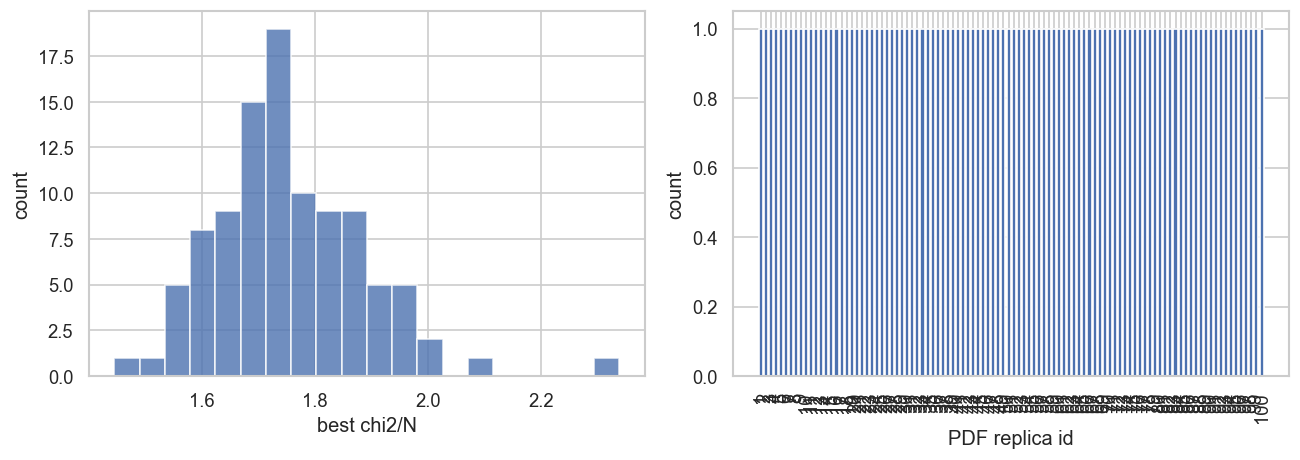

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(replica_results_df["best_chi2dN"], bins=20, alpha=0.8)
axes[0].set_xlabel("best chi2/N")
axes[0].set_ylabel("count")

pdf_counts = replica_results_df["pdf_replica_id"].dropna().astype(int).value_counts().sort_index()
axes[1].bar(pdf_counts.index.astype(str), pdf_counts.values)
axes[1].set_xlabel("PDF replica id")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


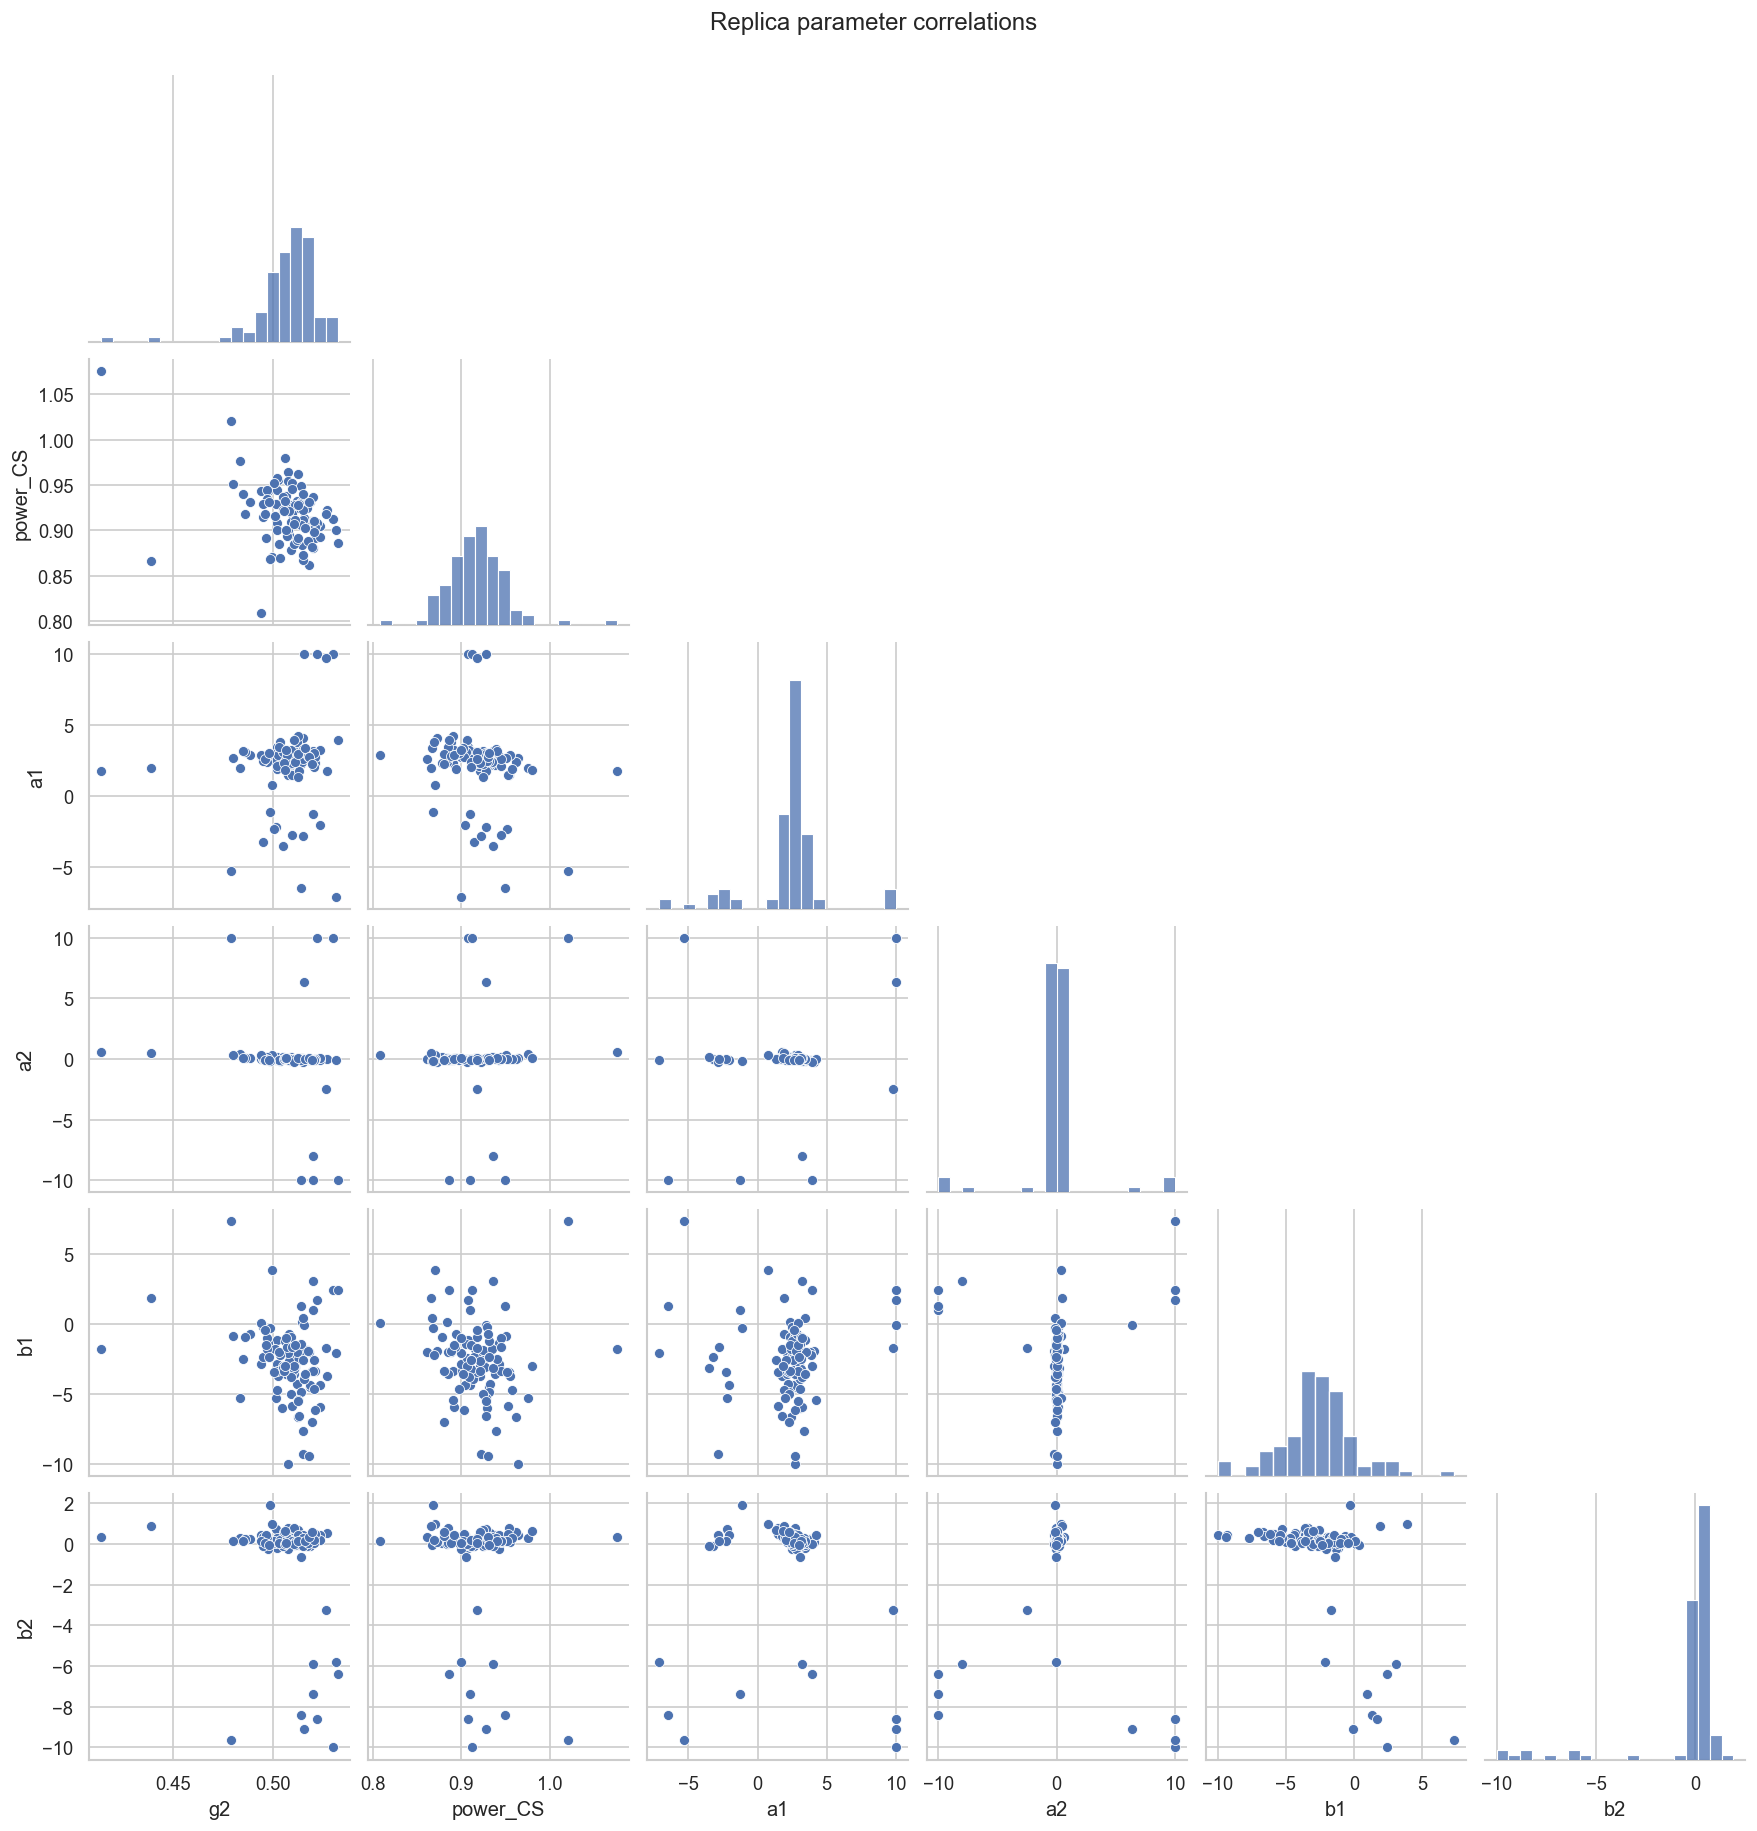

In [7]:
if pairplot_mode == "all":
    pairplot_columns = param_names
else:
    pairplot_columns = [name for i, name in enumerate(param_names) if i not in frozen_set]

plot_df = replica_results_df[pairplot_columns].copy()
g = sns.pairplot(plot_df, corner=True, diag_kind="hist")
g.figure.suptitle("Replica parameter correlations", y=1.02)
plt.show()
